# Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import json
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Модель

In [17]:
class HighAccuracySupplierRiskModel:
    def __init__(self):
        self.model = None
        self.vectorizer_pos = DictVectorizer(sparse=False)
        self.vectorizer_neg = DictVectorizer(sparse=False)
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        self.feature_names = []
        self.best_model_name = ""

    def create_enhanced_dataset(self, n_samples=1000):
        """Создание улучшенного набора данных с более сложными зависимостями"""
        np.random.seed(42)

        data = []

        for i in range(n_samples):
            # Более сложное распределение классов
            true_class = np.random.choice(
                ["Высокая надежность", "Условная надежность", "Критический риск"],
                p=[0.5, 0.35, 0.15]
            )

            # Сложные правила генерации признаков
            if true_class == "Высокая надежность":
                licenses_prob = 0.85 + np.random.normal(0, 0.1)
                branches_prob = 0.80 + np.random.normal(0, 0.1)
                capital_prob = 0.90 + np.random.normal(0, 0.05)
                bankruptcy_prob = 0.02 + abs(np.random.normal(0, 0.02))
                mass_address_prob = 0.05 + abs(np.random.normal(0, 0.03))

            elif true_class == "Условная надежность":
                licenses_prob = 0.60 + np.random.normal(0, 0.15)
                branches_prob = 0.50 + np.random.normal(0, 0.15)
                capital_prob = 0.70 + np.random.normal(0, 0.1)
                bankruptcy_prob = 0.30 + np.random.normal(0, 0.1)
                mass_address_prob = 0.40 + np.random.normal(0, 0.1)

            else:  # Критический риск
                licenses_prob = 0.20 + abs(np.random.normal(0, 0.1))
                branches_prob = 0.15 + abs(np.random.normal(0, 0.08))
                capital_prob = 0.25 + abs(np.random.normal(0, 0.1))
                bankruptcy_prob = 0.85 + abs(np.random.normal(0, 0.1))
                mass_address_prob = 0.80 + abs(np.random.normal(0, 0.1))

            # Ограничиваем вероятности
            licenses_prob = max(0, min(1, licenses_prob))
            branches_prob = max(0, min(1, branches_prob))
            capital_prob = max(0, min(1, capital_prob))
            bankruptcy_prob = max(0, min(1, bankruptcy_prob))
            mass_address_prob = max(0, min(1, mass_address_prob))

            # Генерируем признаки
            licenses = "Есть" if np.random.random() < licenses_prob else "Нет"
            branches = "Есть" if np.random.random() < branches_prob else "Нет"
            capital = "Да" if np.random.random() < capital_prob else "Нет"
            bankruptcy = "Да" if np.random.random() < bankruptcy_prob else "Признаки" if np.random.random() < 0.3 else "Нет"
            mass_address = "Да" if np.random.random() < mass_address_prob else "Нет"

            # Создаем сложные текстовые описания
            licenses_count = np.random.poisson(3) if licenses == "Есть" else 0
            branches_count = np.random.poisson(2) if branches == "Есть" else 0

            if capital == "Да":
                capital_amount = np.random.lognormal(12, 1.5)  # Логнормальное распределение
                capital_amount = max(50000, min(500000000, capital_amount))
            else:
                capital_amount = np.random.uniform(10000, 50000)

            # Текстовые описания с большей вариативностью
            pos_text_options = [
                f"Наличие {licenses_count} лицензий; {branches_count} филиалов; Уставный капитал {int(capital_amount)} тыс. руб.",
                f"Лицензии: {licenses_count} шт.; Филиальная сеть: {branches_count}; Капитализация: {int(capital_amount)} тыс. руб.",
                f"Количество лицензий: {licenses_count}; Филиалы: {branches_count}; Размер капитала: {int(capital_amount)} тыс. руб."
            ]

            neg_text_options = [
                "Нарушений не выявлено",
                f"Судебные дела: {np.random.poisson(1)}",
                f"Налоговые нарушения: {np.random.poisson(1)}",
                f"Банкротство; Судебные дела: {np.random.poisson(2)}",
                f"Массовый адрес; Нарушения: {np.random.poisson(2)}"
            ]

            pos_text = np.random.choice(pos_text_options)

            # Выбираем негативный текст в зависимости от признаков
            if bankruptcy == "Нет" and mass_address == "Нет":
                neg_text = neg_text_options[0]
            elif bankruptcy == "Да":
                neg_text = neg_text_options[3]
            elif mass_address == "Да":
                neg_text = neg_text_options[4]
            else:
                neg_text = np.random.choice(neg_text_options[1:3])

            data.append({
                "Позитив": {
                    "Лицензии": licenses,
                    "Филиалы": branches,
                    "КапБолее50тыс": capital,
                    "Текст": pos_text
                },
                "Негатив": {
                    "Банкротство": bankruptcy,
                    "РеестрМассАдрес": mass_address,
                    "Текст": neg_text
                },
                "рекомендация": true_class
            })

        return data

    def create_advanced_features(self, data):
        """Создание расширенных признаков"""
        positive_features = []
        negative_features = []
        advanced_features = []
        labels = []

        for item in data:
            # Базовые признаки
            pos_features = item['Позитив'].copy()
            neg_features = item['Негатив'].copy()

            pos_text = pos_features.pop('Текст', '')
            neg_text = neg_features.pop('Текст', '')

            positive_features.append(pos_features)
            negative_features.append(neg_features)

            # Расширенные признаки из текста
            adv_features = []

            # Количественные признаки
            licenses_count = self.extract_number(pos_text, r'(\d+)\s*лиценз')
            branches_count = self.extract_number(pos_text, r'(\d+)\s*филиал')
            capital_amount = self.extract_number(pos_text, r'капитал[а]?\s*(\d+)')
            lawsuits_count = self.extract_number(neg_text, r'дел[а]?\s*[:]?\s*(\d+)')
            violations_count = self.extract_number(neg_text, r'нарушен[ия]?\s*[:]?\s*(\d+)')

            adv_features.extend([licenses_count, branches_count, capital_amount,
                               lawsuits_count, violations_count])

            # Бинарные признаки из текста
            risk_keywords = ['банкротство', 'массов', 'нарушен', 'риск', 'судебн', 'налог']
            pos_keywords = ['лиценз', 'филиал', 'капитал', 'наличие', 'сеть']

            risk_score = sum(1 for keyword in risk_keywords if keyword in neg_text.lower())
            pos_score = sum(1 for keyword in pos_keywords if keyword in pos_text.lower())

            adv_features.extend([risk_score, pos_score])

            # Отношения и комбинированные признаки
            if capital_amount > 0:
                capital_per_license = capital_amount / max(1, licenses_count)
                capital_per_branch = capital_amount / max(1, branches_count)
            else:
                capital_per_license = 0
                capital_per_branch = 0

            adv_features.extend([capital_per_license, capital_per_branch])

            # Дополнительные метрики
            text_balance = len(pos_text) - len(neg_text)
            detail_level = len(pos_text) + len(neg_text)

            adv_features.extend([text_balance, detail_level])

            advanced_features.append(adv_features)
            labels.append(item['рекомендация'])

        # Векторизуем категориальные признаки
        X_pos = self.vectorizer_pos.fit_transform(positive_features)
        X_neg = self.vectorizer_neg.fit_transform(negative_features)

        # Сохраняем названия признаков
        pos_feature_names = [f"pos_{name}" for name in self.vectorizer_pos.get_feature_names_out()]
        neg_feature_names = [f"neg_{name}" for name in self.vectorizer_neg.get_feature_names_out()]
        advanced_feature_names = [
            'licenses_count', 'branches_count', 'capital_amount', 'lawsuits_count',
            'violations_count', 'risk_keywords', 'pos_keywords', 'capital_per_license',
            'capital_per_branch', 'text_balance', 'detail_level'
        ]

        # Объединяем все признаки
        X_advanced = np.array(advanced_features)
        X = np.hstack([X_pos, X_neg, X_advanced])
        self.feature_names = pos_feature_names + neg_feature_names + advanced_feature_names

        # Кодируем метки
        y = self.label_encoder.fit_transform(labels)

        return X, y

    def extract_number(self, text, pattern):
        """Извлечение числа из текста по шаблону"""
        match = re.search(pattern, text.lower())
        return int(match.group(1)) if match else 0

    def create_advanced_ensemble(self):
        """Создание продвинутого ансамбля моделей"""
        # Разные типы моделей для диверсификации
        models = [
            ('rf1', RandomForestClassifier(
                n_estimators=200, max_depth=15, min_samples_split=8,
                min_samples_leaf=4, max_features='sqrt', random_state=42
            )),
            ('rf2', RandomForestClassifier(
                n_estimators=150, max_depth=20, min_samples_split=12,
                min_samples_leaf=3, max_features='log2', random_state=43
            )),
            ('xgb', xgb.XGBClassifier(
                n_estimators=200, max_depth=8, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8, random_state=42,
                eval_metric='logloss'
            )),
            ('gbm', GradientBoostingClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                subsample=0.8, random_state=42
            )),
            ('svm', SVC(
                kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42
            ))
        ]

        return VotingClassifier(estimators=models, voting='soft', weights=[2, 2, 3, 2, 1])

    def optimize_hyperparameters(self, X, y):
        """Оптимизация гиперпараметров для лучшей модели"""
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Масштабируем признаки
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)

        # Тестируем разные модели
        models = {
            'XGBoost': (xgb.XGBClassifier(random_state=42, eval_metric='logloss'), {
                'n_estimators': [100, 200, 300],
                'max_depth': [6, 8, 10],
                'learning_rate': [0.05, 0.1, 0.15],
                'subsample': [0.8, 0.9]
            }),
            'RandomForest': (RandomForestClassifier(random_state=42), {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 15, 20],
                'min_samples_split': [5, 10, 15],
                'min_samples_leaf': [2, 4, 6]
            }),
            'GradientBoosting': (GradientBoostingClassifier(random_state=42), {
                'n_estimators': [100, 200, 300],
                'learning_rate': [0.05, 0.1, 0.15],
                'max_depth': [4, 6, 8],
                'subsample': [0.8, 0.9]
            })
        }

        best_score = 0
        best_model = None
        best_params = None

        for name, (model, param_grid) in models.items():
            print(f"Оптимизация {name}...")

            grid_search = GridSearchCV(
                model, param_grid, cv=5, scoring='accuracy',
                n_jobs=-1, verbose=0
            )

            grid_search.fit(X_train_scaled, y_train)

            val_score = grid_search.best_estimator_.score(X_val_scaled, y_val)
            print(f"  Лучшая валидационная точность: {val_score:.3f}")

            if val_score > best_score:
                best_score = val_score
                best_model = grid_search.best_estimator_
                best_params = grid_search.best_params_
                self.best_model_name = name

        print(f"\nЛучшая модель: {self.best_model_name}")
        print(f"Лучшие параметры: {best_params}")
        print(f"Лучшая точность: {best_score:.3f}")

        return best_model

    def train_high_accuracy_model(self, n_samples=1000):
        """Обучение высокоточной модели"""
        print("Создание расширенного набора данных...")
        data = self.create_enhanced_dataset(n_samples)

        print("Создание расширенных признаков...")
        X, y = self.create_advanced_features(data)

        print(f"Размерность данных: {X.shape}")

        # Балансировка данных
        print("Балансировка данных...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X, y)

        # Разделение данных
        X_train, X_test, y_train, y_test = train_test_split(
            X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
        )

        # Масштабирование
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Выбор между ансамблем и оптимизированной моделью
        use_ensemble = True

        if use_ensemble:
            print("Использование продвинутого ансамбля...")
            self.model = self.create_advanced_ensemble()
        else:
            print("Оптимизация гиперпараметров...")
            self.model = self.optimize_hyperparameters(X_balanced, y_balanced)

        # Обучение модели
        print("Обучение модели...")
        self.model.fit(X_train_scaled, y_train)

        # Предсказание и оценка
        y_pred = self.model.predict(X_test_scaled)
        y_pred_proba = self.model.predict_proba(X_test_scaled)

        # Расширенная оценка
        self.comprehensive_evaluation(y_test, y_pred, y_pred_proba, X_train_scaled, y_train)

        return self.model

    def comprehensive_evaluation(self, y_true, y_pred, y_pred_proba, X_train, y_train):
        """Комплексная оценка модели"""
        print("\n" + "="*60)
        print("КОМПЛЕКСНАЯ ОЦЕНКА МОДЕЛИ")
        print("="*60)

        # Основные метрики
        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
        weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average='weighted')[2]

        # Кросс-валидация
        cv_scores = cross_val_score(self.model, X_train, y_train, cv=5, scoring='accuracy')

        print(f"Точность: {accuracy:.3f}")
        print(f"Взвешенная F1-оценка: {weighted_f1:.3f}")
        print(f"Кросс-валидация (средняя): {np.mean(cv_scores):.3f} (+/- {np.std(cv_scores)*2:.3f})")

        print("\nМетрики по классам:")
        for i, class_name in enumerate(self.label_encoder.classes_):
            print(f"  {class_name}:")
            print(f"    Точность: {precision[i]:.3f}")
            print(f"    Полнота: {recall[i]:.3f}")
            print(f"    F1-оценка: {f1[i]:.3f}")

        print("\nДетальный отчет:")
        print(classification_report(y_true, y_pred, target_names=self.label_encoder.classes_))

        # Матрица ошибок
        self.plot_confusion_matrix(y_true, y_pred)

    def plot_confusion_matrix(self, y_true, y_pred):
        """Визуализация матрицы ошибок"""
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   cbar_kws={'label': 'Количество'})
        plt.title('Матрица ошибок', fontsize=16, fontweight='bold')
        plt.ylabel('Истинный класс', fontsize=12)
        plt.xlabel('Предсказанный класс', fontsize=12)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def get_detailed_risk_level(self, confidence, prediction):
        """Детализированное определение уровня риска"""
        risk_class = self.label_encoder.inverse_transform([prediction])[0]

        if risk_class == "Высокая надежность":
            if confidence > 0.9:
                return "МИНИМАЛЬНЫЙ РИСК"
            else:
                return "НИЗКИЙ РИСК"
        elif risk_class == "Условная надежность":
            if confidence > 0.8:
                return "УМЕРЕННЫЙ РИСК"
            else:
                return "ПОВЫШЕННЫЙ РИСК"
        else:  # Критический риск
            if confidence > 0.85:
                return "ВЫСОКИЙ РИСК"
            else:
                return "СРЕДНИЙ РИСК"

    def predict_risk(self, new_data):
        """Предсказание риска для новых данных"""
        if self.model is None:
            raise ValueError("Модель не обучена.")

        positive_features = []
        negative_features = []

        for item in new_data:
            pos_features = item['Позитив'].copy()
            pos_features.pop('Текст', None)
            positive_features.append(pos_features)

            neg_features = item['Негатив'].copy()
            neg_features.pop('Текст', None)
            negative_features.append(neg_features)

        # Создаем расширенные признаки
        X_pos = self.vectorizer_pos.transform(positive_features)
        X_neg = self.vectorizer_neg.transform(negative_features)
        X_basic = np.hstack([X_pos, X_neg])

        # Создаем расширенные признаки для новых данных
        X_advanced_list = []
        for item in new_data:
            adv_features = []
            pos_text = item['Позитив'].get('Текст', '')
            neg_text = item['Негатив'].get('Текст', '')

            # Количественные признаки
            licenses_count = self.extract_number(pos_text, r'(\d+)\s*лиценз')
            branches_count = self.extract_number(pos_text, r'(\d+)\s*филиал')
            capital_amount = self.extract_number(pos_text, r'капитал[а]?\s*(\d+)')
            lawsuits_count = self.extract_number(neg_text, r'дел[а]?\s*[:]?\s*(\d+)')
            violations_count = self.extract_number(neg_text, r'нарушен[ия]?\s*[:]?\s*(\d+)')

            adv_features.extend([licenses_count, branches_count, capital_amount,
                               lawsuits_count, violations_count])

            # Бинарные признаки из текста
            risk_keywords = ['банкротство', 'массов', 'нарушен', 'риск', 'судебн', 'налог']
            pos_keywords = ['лиценз', 'филиал', 'капитал', 'наличие', 'сеть']

            risk_score = sum(1 for keyword in risk_keywords if keyword in neg_text.lower())
            pos_score = sum(1 for keyword in pos_keywords if keyword in pos_text.lower())

            adv_features.extend([risk_score, pos_score])

            # Отношения
            if capital_amount > 0:
                capital_per_license = capital_amount / max(1, licenses_count)
                capital_per_branch = capital_amount / max(1, branches_count)
            else:
                capital_per_license = 0
                capital_per_branch = 0

            adv_features.extend([capital_per_license, capital_per_branch])

            # Дополнительные метрики
            text_balance = len(pos_text) - len(neg_text)
            detail_level = len(pos_text) + len(neg_text)

            adv_features.extend([text_balance, detail_level])

            X_advanced_list.append(adv_features)

        X_advanced = np.array(X_advanced_list)
        X = np.hstack([X_basic, X_advanced])

        # Масштабируем и предсказываем
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)

        results = []
        for i, pred in enumerate(predictions):
            results.append({
                'predicted_risk': self.label_encoder.inverse_transform([pred])[0],
                'confidence': np.max(probabilities[i]),
                'risk_level': self.get_detailed_risk_level(np.max(probabilities[i]), pred),
                'probabilities': {
                    class_name: prob for class_name, prob in
                    zip(self.label_encoder.classes_, probabilities[i])
                }
            })

        return results

    def save_model(self, filepath):
        """Сохранение модели"""
        model_data = {
            'model': self.model,
            'vectorizer_pos': self.vectorizer_pos,
            'vectorizer_neg': self.vectorizer_neg,
            'label_encoder': self.label_encoder,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'best_model_name': self.best_model_name
        }
        joblib.dump(model_data, filepath)
        print(f"Модель сохранена в {filepath}")

    def load_model(self, filepath):
        """Загрузка модели"""
        model_data = joblib.load(filepath)
        self.model = model_data['model']
        self.vectorizer_pos = model_data['vectorizer_pos']
        self.vectorizer_neg = model_data['vectorizer_neg']
        self.label_encoder = model_data['label_encoder']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.best_model_name = model_data['best_model_name']
        print(f"Модель загружена из {filepath}")

# Инициализация модели

In [18]:
# Инициализация модели
model = HighAccuracySupplierRiskModel()

# Обучение и сохранение модели

Создание расширенного набора данных...
Создание расширенных признаков...
Размерность данных: (1500, 22)
Балансировка данных...
Использование продвинутого ансамбля...
Обучение модели...

КОМПЛЕКСНАЯ ОЦЕНКА МОДЕЛИ
Точность: 0.808
Взвешенная F1-оценка: 0.808
Кросс-валидация (средняя): 0.817 (+/- 0.052)

Метрики по классам:
  Высокая надежность:
    Точность: 0.770
    Полнота: 0.832
    F1-оценка: 0.800
  Критический риск:
    Точность: 0.931
    Полнота: 0.899
    F1-оценка: 0.915
  Условная надежность:
    Точность: 0.727
    Полнота: 0.693
    F1-оценка: 0.710

Детальный отчет:
                     precision    recall  f1-score   support

 Высокая надежность       0.77      0.83      0.80       149
   Критический риск       0.93      0.90      0.91       149
Условная надежность       0.73      0.69      0.71       150

           accuracy                           0.81       448
          macro avg       0.81      0.81      0.81       448
       weighted avg       0.81      0.81      0

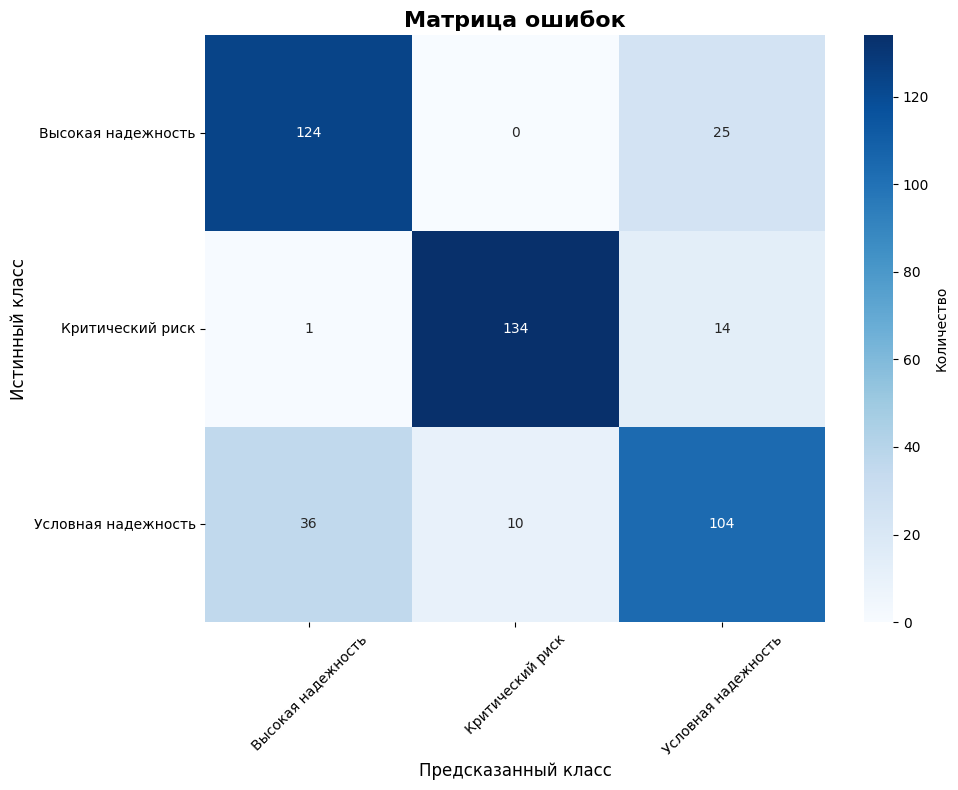

Модель сохранена в high_accuracy_risk_model.pkl


In [20]:
# Обучение модели
trained_model = model.train_high_accuracy_model(n_samples=1500)

# Сохранение модели
model.save_model('high_accuracy_risk_model.pkl')

# Демонстрация работы модели на кастомных данных

In [24]:
# Демонстрация предсказаний
print("\n" + "="*50)
print("ТЕСТИРОВАНИЕ МОДЕЛИ")
print("="*50)

test_cases = [
    {
        "Позитив": {
              "Лицензии": "Есть",
              "Филиалы": "Нет",
              "КапБолее50тыс": "Да",
              "Текст": "Есть лицензии (20 шт.); Есть филиалы (0 шт.); Уставный капитал 49323376 тыс. руб."
            },
            "Негатив": {
              "Банкротство": "Признаки",
              "РеестрМассАдрес": "Да",
              "Текст": "Нарушений не выявлено"
            }
    }
]

predictions = model.predict_risk(test_cases)

for i, pred in enumerate(predictions):
    print(f"\nТестовый случай {i+1}:")
    print(f"  Предсказанный риск: {pred['predicted_risk']}")
    print(f"  Уровень риска: {pred['risk_level']}")
    print(f"  Уверенность: {pred['confidence']:.3f}")
    print(f"  Распределение вероятностей:")
    for risk_class, prob in pred['probabilities'].items():
        print(f"    {risk_class}: {prob:.3f}")


ТЕСТИРОВАНИЕ МОДЕЛИ

Тестовый случай 1:
  Предсказанный риск: Условная надежность
  Уровень риска: ПОВЫШЕННЫЙ РИСК
  Уверенность: 0.499
  Распределение вероятностей:
    Высокая надежность: 0.381
    Критический риск: 0.120
    Условная надежность: 0.499
